# Differentiation Analysis — How the ML System and Controller Distinguish Cases

**No training. Loads pretrained checkpoints and produces differentiation-focused analysis figures/tables.**

Required Kaggle dataset inputs:
- `wound-datasets` (test images + masks)
- `polar-v2-weights` (contains `best.pth`)
- `detr-extended-weights` (contains `best.pth`)
- `autoregressive-extended-weights` (contains `best.pth`)

This notebook helps answer: *How does the system differentiate one case from another?*

In [1]:
import os, json, math, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import warnings

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as T
import torchvision.models as models

warnings.filterwarnings('ignore')
assert torch.cuda.is_available(), 'No GPU! Select T4 x2 in Kaggle Settings.'
device = torch.device('cuda')
print(f'GPU: {torch.cuda.get_device_name(0)} | PyTorch: {torch.__version__}')

IMAGE_SIZE = 256
NUM_RADII_64 = 64
NUM_RADII_128 = 128
D_MODEL = 256
IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]
MEAN_T = torch.tensor(MEAN).view(3,1,1)
STD_T  = torch.tensor(STD).view(3,1,1)

Path('figures').mkdir(exist_ok=True)
Path('results').mkdir(exist_ok=True)
print('Setup complete.')

GPU: Tesla T4 | PyTorch: 2.10.0+cu128
Setup complete.


## 1) Load test images (same pattern as Notebook 03)

In [2]:
_candidates = [
    Path('/kaggle/input/datasets/dianisay/wound-datasets/Datasets'),
    Path('/kaggle/input/wound-datasets/Datasets'),
    Path('/kaggle/input/datasets/dianisay/wound-datasets'),
    Path('/kaggle/input/wound-datasets'),
]
BASE_PATH = next((p for p in _candidates if p.exists()), _candidates[0])
print(f'BASE_PATH: {BASE_PATH} (exists={BASE_PATH.exists()})')

WOUND_DATASETS = [
    {'name': 'Medetec', 'root': BASE_PATH / 'Medetec_foot_ulcer_224',
     'splits': {'test': ('test/images', 'test/labels')}},
    {'name': 'AZH', 'root': BASE_PATH / 'wound_dataset' / 'azh_wound_care_center_dataset_patches',
     'splits': {'test': ('test/images', 'test/labels')}},
]

# Slightly larger sample than notebook 03 for analysis robustness
IMAGES_PER_DATASET = 12
fixed_images = []
for ds in WOUND_DATASETS:
    root = ds['root']
    if not root.exists():
        print(f'  {ds["name"]}: NOT FOUND at {root}')
        continue

    img_rel, lbl_rel = ds['splits']['test']
    img_dir = root / img_rel
    lbl_dir = root / lbl_rel
    if not img_dir.exists() or not lbl_dir.exists():
        print(f'  {ds["name"]}: dirs not found')
        continue

    imgs = sorted([p for p in img_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS])
    lbl_files = {p.stem.lower(): p for p in lbl_dir.iterdir() if p.suffix.lower() in IMAGE_EXTS}

    count = 0
    for img_p in imgs:
        if count >= IMAGES_PER_DATASET:
            break
        mask_p = lbl_files.get(img_p.stem.lower())
        if not mask_p:
            continue

        raw_mask = np.array(Image.open(mask_p).convert('L').resize((IMAGE_SIZE, IMAGE_SIZE), Image.NEAREST))
        if raw_mask.max() <= 1:
            raw_mask = raw_mask * 255
        gt_bin = (raw_mask > 127).astype(np.uint8)
        if gt_bin.sum() < 50:
            continue

        img_pil = Image.open(img_p).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        img_np = np.array(img_pil)
        img_t = torch.from_numpy(img_np.copy()).float().permute(2,0,1) / 255.0
        img_t = T.Normalize(MEAN, STD)(img_t)

        fixed_images.append({
            'ds_name': ds['name'],
            'image': img_t,
            'raw_mask': gt_bin,
            'filename': img_p.name,
            'image_path': str(img_p),
            'mask_path': str(mask_p),
        })
        count += 1

    print(f'  {ds["name"]}: {count} images selected')

print(f'\nTotal fixed images: {len(fixed_images)}')
print(f'Datasets in sample: {sorted(set(f["ds_name"] for f in fixed_images))}')

BASE_PATH: /kaggle/input/datasets/dianisay/wound-datasets/Datasets (exists=True)
  Medetec: 8 images selected
  AZH: 12 images selected

Total fixed images: 20
Datasets in sample: ['AZH', 'Medetec']


## 2) Model architectures (faithful ports of the trained checkpoints)

These classes are ported verbatim (module names, shapes, hyperparameters) from the training notebooks so the saved `state_dict`s load correctly:
- `CNNTransformerEncoder`, `PerAngleAttentionDecoder`, `FourierDescriptorHead`, `PolarModelV2` → `notebooks/01-ablation-study-polar-kaggle-extended.ipynb` (ResNet-50 truncated after `layer3`, 128 radii).
- `CNNTransformerEncoder`, `DETRDecoder` → `notebooks/01-ablation-study-detr-kaggle-extended.ipynb` (64 radii/points).
- `CNNTransformerEncoder`, `AutoregressiveDecoder` → `notebooks/01-ablation-study-autoregressive-kaggle-extended.ipynb` (64 radii).

Backbones are instantiated with `pretrained=False` (`weights=None`) because the trusted checkpoints below restore every required weight — no ImageNet download is needed or attempted at inference time.

In [3]:
# ─────────────────────────────────────────────────────────────────────────
# Shared encoder — ported verbatim from the *-kaggle-extended training
# notebooks (ResNet-50 backbone truncated after layer3 + Transformer).
# Used both standalone (DETR/Autoregressive) and inside PolarModelV2.
# ─────────────────────────────────────────────────────────────────────────
class CNNTransformerEncoder(nn.Module):
    def __init__(self, d_model=D_MODEL, nhead=8, num_layers=2,
                 pretrained=False, dropout=0.1):
        super().__init__()
        # pretrained=False (weights=None): inference restores all weights from
        # the trusted checkpoint, so no ImageNet download is needed/attempted.
        backbone = models.resnet50(weights='DEFAULT' if pretrained else None)
        # Use up to layer3 (stride 16) -> 16x16 feature map for 256x256 input
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu, backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3,
        )  # out: (B, 1024, H/16, W/16)
        self.proj = nn.Conv2d(1024, d_model, 1)
        # 256 = (256/16)^2 spatial tokens
        self.pos_embed = nn.Parameter(torch.randn(1, 256, d_model) * 0.02)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.d_model = d_model

    def forward(self, x):
        feat = self.backbone(x)                    # (B, 1024, 16, 16)
        feat = self.proj(feat)                      # (B, d_model, 16, 16)
        B, C, H, W = feat.shape
        tokens = feat.flatten(2).transpose(1, 2)     # (B, HW, d_model)
        tokens = tokens + self.pos_embed[:, :tokens.size(1)]
        memory = self.transformer(tokens)            # (B, HW, d_model)
        return memory


# ─────────────────────────────────────────────────────────────────────────
# Polar v2 — ported verbatim from
# notebooks/01-ablation-study-polar-kaggle-extended.ipynb
# (PerAngleAttentionDecoder + FourierDescriptorHead, 128 radii)
# ─────────────────────────────────────────────────────────────────────────
class PerAngleAttentionDecoder(nn.Module):
    """Each radius gets its own query attending to spatial features."""
    def __init__(self, d_model=D_MODEL, nhead=8, num_radii=NUM_RADII_128, num_layers=2):
        super().__init__()
        self.num_radii = num_radii
        self.queries = nn.Parameter(torch.randn(1, num_radii + 1, d_model) * 0.02)
        angles = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        ang_enc = torch.stack([angles.cos(), angles.sin()], dim=-1)
        ang_enc_full = torch.zeros(num_radii + 1, d_model)
        ang_enc_full[:num_radii, :2] = ang_enc
        self.register_buffer('ang_encoding', ang_enc_full.unsqueeze(0))
        dec_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4, dropout=0.1, batch_first=True)
        self.cross_attn = nn.TransformerDecoder(dec_layer, num_layers=num_layers)
        self.centroid_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2))
        self.radii_head = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 1))
        self._angles = nn.Parameter(torch.arange(num_radii).float() * (2*math.pi/num_radii), requires_grad=False)

    def forward(self, memory):
        B = memory.size(0)
        q = (self.queries + self.ang_encoding).expand(B, -1, -1)
        out = self.cross_attn(q, memory)
        cx_cy = torch.sigmoid(self.centroid_head(out[:, -1]))
        r = torch.sigmoid(self.radii_head(out[:, :-1])).squeeze(-1) * 0.7
        ang = self._angles.unsqueeze(0)
        px = cx_cy[:, 0:1] + r * torch.cos(ang)
        py = cx_cy[:, 1:2] + r * torch.sin(ang)
        pts = torch.stack([px, py], dim=-1)
        return {'centroid': cx_cy, 'radii': r, 'points': pts}


class FourierDescriptorHead(nn.Module):
    """Auxiliary: predicts Fourier coefficients for smoothness regularization."""
    def __init__(self, d_model=D_MODEL, n_coeffs=32, num_radii=NUM_RADII_128):
        super().__init__()
        self.n_coeffs = n_coeffs
        self.head = nn.Sequential(nn.Linear(d_model, 256), nn.ReLU(), nn.Dropout(0.1),
                                  nn.Linear(256, 2 * n_coeffs))
        t = torch.arange(num_radii).float() * (2 * math.pi / num_radii)
        k = torch.arange(n_coeffs).float()
        self.register_buffer('cos_basis', torch.cos(t.unsqueeze(1) * k.unsqueeze(0)))
        self.register_buffer('sin_basis', torch.sin(t.unsqueeze(1) * k.unsqueeze(0)))

    def forward(self, global_feat):
        coeffs = self.head(global_feat)
        a, b = coeffs[:, :self.n_coeffs], coeffs[:, self.n_coeffs:]
        radii = torch.sigmoid(a @ self.cos_basis.T + b @ self.sin_basis.T) * 0.7
        return radii


class PolarModelV2(nn.Module):
    """Encoder + Per-Angle Attention + Fourier regularizer (thesis model)."""
    def __init__(self, d_model=D_MODEL, num_radii=NUM_RADII_128, pretrained=False):
        super().__init__()
        self.encoder = CNNTransformerEncoder(d_model=d_model, pretrained=pretrained)
        self.decoder = PerAngleAttentionDecoder(d_model=d_model, num_radii=num_radii)
        self.fourier_head = FourierDescriptorHead(d_model=d_model, n_coeffs=32, num_radii=num_radii)

    def forward(self, x):
        memory = self.encoder(x)
        polar_out = self.decoder(memory)
        global_feat = memory.mean(dim=1)
        fourier_radii = self.fourier_head(global_feat)
        return {**polar_out, 'fourier_radii': fourier_radii}


# ─────────────────────────────────────────────────────────────────────────
# DETR + Autoregressive decoders — ported verbatim from
# notebooks/01-ablation-study-detr-kaggle-extended.ipynb and
# notebooks/01-ablation-study-autoregressive-kaggle-extended.ipynb
# (64 radii/points; share the CNNTransformerEncoder above)
# ─────────────────────────────────────────────────────────────────────────
class DETRDecoder(nn.Module):
    """Cross-attention decoder predicting boundary point set + centroid."""
    def __init__(self, d_model=D_MODEL, nhead=8, num_layers=3,
                 num_points=NUM_RADII_64, dropout=0.1):
        super().__init__()
        self.num_points = num_points
        self.queries = nn.Embedding(num_points + 1, d_model)  # +1 for centroid
        decoder_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model*4,
            dropout=dropout, batch_first=True,
        )
        self.transformer = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.point_head    = nn.Linear(d_model, 2)
        self.centroid_head = nn.Linear(d_model, 2)
        self.radii_head    = nn.Linear(d_model, 1)
        self._angles = nn.Parameter(
            torch.linspace(0, 2*math.pi, num_points, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, memory):
        B = memory.size(0)
        q = self.queries.weight.unsqueeze(0).expand(B, -1, -1)  # (B, N+1, d)
        out = self.transformer(q, memory)                         # (B, N+1, d)
        pts      = torch.sigmoid(self.point_head(out[:, 1:]))    # (B, N, 2)
        centroid = torch.sigmoid(self.centroid_head(out[:, 0]))  # (B, 2)
        c = centroid.unsqueeze(1)  # (B, 1, 2)
        diff = pts - c
        r = torch.sqrt((diff**2).sum(-1) + 1e-8)                 # (B, N)
        return {'centroid': centroid, 'radii': r, 'points': pts}


class AutoregressiveDecoder(nn.Module):
    """GRU-based sequential decoder predicting one radius per time step."""
    def __init__(self, d_model=D_MODEL, hidden=512, num_radii=NUM_RADII_64):
        super().__init__()
        self.num_radii = num_radii
        self.context   = nn.Linear(d_model, hidden)   # memory -> init hidden
        self.gru       = nn.GRUCell(input_size=1, hidden_size=hidden)
        self.out_head  = nn.Linear(hidden, 1)
        self.centroid_head = nn.Sequential(
            nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 2)
        )
        self._angles = nn.Parameter(
            torch.linspace(0, 2*math.pi, num_radii, dtype=torch.float32),
            requires_grad=False,
        )

    def forward(self, memory):
        B = memory.size(0)
        z = memory.mean(1)                             # (B, d_model) global ctx
        h = torch.tanh(self.context(z))                # (B, hidden)
        centroid = torch.sigmoid(self.centroid_head(z))

        radii_list = []
        x = torch.zeros(B, 1, device=memory.device)    # start token
        for _ in range(self.num_radii):
            h = self.gru(x, h)
            r = torch.sigmoid(self.out_head(h)) * 0.5   # (B, 1)
            radii_list.append(r)
            x = r.detach()
        radii = torch.cat(radii_list, dim=1)            # (B, num_radii)

        ang  = self._angles.unsqueeze(0)
        cx   = centroid[:, 0:1]
        cy   = centroid[:, 1:2]
        pts  = torch.stack([cx + radii * torch.cos(ang),
                            cy + radii * torch.sin(ang)], dim=-1)  # (B, N, 2)
        return {'centroid': centroid, 'radii': radii, 'points': pts}


print('Architectures defined (faithful ports of trained checkpoints).')

Architectures defined (faithful ports of trained checkpoints).


## 3) Load checkpoints

In [4]:
def find_checkpoint(name, candidates):
    for p in candidates:
        if p.exists():
            print(f'  {name}: {p}')
            return p
    print(f'  {name}: NOT FOUND')
    return None

polar_ckpt = find_checkpoint('Polar v2', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/Polar/best.pth'),
    Path('/kaggle/input/polar-v2-weights/checkpoints/best.pth'),
])

detr_ckpt = find_checkpoint('DETR extended', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/DETR/best.pth'),
    Path('/kaggle/input/detr-extended-weights/checkpoints/best.pth'),
])

ar_ckpt = find_checkpoint('Autoregressive extended', [
    Path('/kaggle/input/datasets/dianisay/trainedmodels/Models/Autoregressive/best.pth'),
    Path('/kaggle/input/autoregressive-extended-weights/checkpoints/best.pth'),
])

  Polar v2: /kaggle/input/datasets/dianisay/trainedmodels/Models/Polar/best.pth
  DETR extended: /kaggle/input/datasets/dianisay/trainedmodels/Models/DETR/best.pth
  Autoregressive extended: /kaggle/input/datasets/dianisay/trainedmodels/Models/Autoregressive/best.pth


In [5]:
def load_trusted_checkpoint(path, map_location=None):
    """Load a checkpoint we trust because it was produced by our own training
    notebooks (notebooks/01-ablation-study-*-kaggle-extended.ipynb).

    PyTorch >= 2.6 changed torch.load's default to weights_only=True, which
    uses a restricted unpickler. Our checkpoints store a 'history' dict
    containing numpy scalar values (numpy._core.multiarray.scalar), which the
    restricted unpickler rejects even though the file is fully trusted (we
    produced it ourselves in this project). We therefore explicitly opt into
    full unpickling here.

    IMPORTANT: this loader must ONLY be used for the trusted checkpoints
    trained by this project. Never reuse it for third-party / untrusted
    checkpoint files, since weights_only=False can execute arbitrary code
    embedded in a malicious pickle.
    """
    return torch.load(path, map_location=map_location, weights_only=False)


def strict_load(module, state_dict, label):
    """Load a state dict with strict=True. Missing keys, unexpected keys, and
    shape mismatches are never silently ignored: they raise immediately with
    a message pointing at the likely cause (architecture drift between this
    notebook and the training notebook that produced the checkpoint)."""
    try:
        module.load_state_dict(state_dict, strict=True)
    except RuntimeError as e:
        raise RuntimeError(
            f'Incompatible checkpoint for {label}: the architecture defined in '
            f'this notebook does not match the saved state_dict (missing keys, '
            f'unexpected keys, or shape mismatch). This usually means the model '
            f'class here has drifted from the training notebook. Original '
            f'error:\n{e}'
        ) from e
    return module


models_loaded = []

if polar_ckpt is not None:
    m = PolarModelV2(pretrained=False).to(device).eval()
    ck = load_trusted_checkpoint(polar_ckpt, map_location=device)
    state = ck['model_state'] if isinstance(ck, dict) and 'model_state' in ck else ck
    strict_load(m, state, 'Polar v2 (PolarModelV2)')
    models_loaded.append(('Polar v2', m, 'polar_v2'))
    print(f'  Polar v2 loaded OK (strict) from {polar_ckpt}')

if detr_ckpt is not None:
    enc = CNNTransformerEncoder(pretrained=False).to(device).eval()
    dec = DETRDecoder(num_points=NUM_RADII_64).to(device).eval()
    ck = load_trusted_checkpoint(detr_ckpt, map_location=device)
    if not (isinstance(ck, dict) and 'encoder_state' in ck and 'decoder_state' in ck):
        raise RuntimeError(
            f"DETR checkpoint at {detr_ckpt} does not have the expected "
            f"'encoder_state'/'decoder_state' format produced by "
            f"01-ablation-study-detr-kaggle-extended.ipynb."
        )
    strict_load(enc, ck['encoder_state'], 'DETR extended (encoder)')
    strict_load(dec, ck['decoder_state'], 'DETR extended (decoder)')
    models_loaded.append(('DETR extended', (enc, dec), 'detr_extended'))
    print(f'  DETR extended loaded OK (strict) from {detr_ckpt}')

if ar_ckpt is not None:
    enc = CNNTransformerEncoder(pretrained=False).to(device).eval()
    dec = AutoregressiveDecoder(num_radii=NUM_RADII_64).to(device).eval()
    ck = load_trusted_checkpoint(ar_ckpt, map_location=device)
    if not (isinstance(ck, dict) and 'encoder_state' in ck and 'decoder_state' in ck):
        raise RuntimeError(
            f"Autoregressive checkpoint at {ar_ckpt} does not have the expected "
            f"'encoder_state'/'decoder_state' format produced by "
            f"01-ablation-study-autoregressive-kaggle-extended.ipynb."
        )
    strict_load(enc, ck['encoder_state'], 'Autoregressive extended (encoder)')
    strict_load(dec, ck['decoder_state'], 'Autoregressive extended (decoder)')
    models_loaded.append(('Autoregressive extended', (enc, dec), 'autoregressive_extended'))
    print(f'  Autoregressive extended loaded OK (strict) from {ar_ckpt}')

print(f'Loaded models: {[m[0] for m in models_loaded]}')
assert len(models_loaded) > 0, 'No models loaded. Check Kaggle input datasets/paths.'

  Polar v2 loaded OK (strict) from /kaggle/input/datasets/dianisay/trainedmodels/Models/Polar/best.pth
  DETR extended loaded OK (strict) from /kaggle/input/datasets/dianisay/trainedmodels/Models/DETR/best.pth
  Autoregressive extended loaded OK (strict) from /kaggle/input/datasets/dianisay/trainedmodels/Models/Autoregressive/best.pth
Loaded models: ['Polar v2', 'DETR extended', 'Autoregressive extended']


## 4) Utility functions for differentiation metrics

In [6]:
def predict_points(model_entry, img_t):
    name, model_or_tuple, mtype = model_entry
    with torch.no_grad():
        if mtype == 'polar_v2':
            out = model_or_tuple(img_t.unsqueeze(0).to(device))
            pts = out['points'][0].detach().cpu().numpy()
        else:
            enc, dec = model_or_tuple
            mem = enc(img_t.unsqueeze(0).to(device))
            out = dec(mem)
            pts = out['points'][0].detach().cpu().numpy()
    pts = np.clip(pts, 0.0, 1.0)
    return pts * IMAGE_SIZE

def polygon_to_mask(pts, size=IMAGE_SIZE):
    m = np.zeros((size, size), dtype=np.uint8)
    pts_i = np.round(pts).astype(np.int32)
    pts_i[:,0] = np.clip(pts_i[:,0], 0, size-1)
    pts_i[:,1] = np.clip(pts_i[:,1], 0, size-1)
    if len(pts_i) >= 3:
        cv2.fillPoly(m, [pts_i], 1)
    return m

def iou_score(pred_mask, gt_mask):
    inter = float((pred_mask & gt_mask).sum())
    union = float((pred_mask | gt_mask).sum())
    return inter/union if union > 0 else 0.0

def dice_score(pred_mask, gt_mask):
    inter = float((pred_mask & gt_mask).sum())
    den = float(pred_mask.sum() + gt_mask.sum())
    return (2*inter)/den if den > 0 else 0.0

def boundary_points(mask):
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if len(cnts) == 0:
        return np.zeros((0,2), dtype=np.float32)
    c = max(cnts, key=lambda x: x.shape[0]).squeeze()
    if c.ndim == 1:
        return np.zeros((0,2), dtype=np.float32)
    return c.astype(np.float32)

def symmetric_boundary_distance(mask_a, mask_b):
    # Approximate boundary disagreement using distance transforms
    ba = boundary_points(mask_a)
    bb = boundary_points(mask_b)
    if len(ba) == 0 or len(bb) == 0:
        return np.nan

    inv_a = (1 - mask_a).astype(np.uint8)
    inv_b = (1 - mask_b).astype(np.uint8)
    dt_a = cv2.distanceTransform(inv_a, cv2.DIST_L2, 3)
    dt_b = cv2.distanceTransform(inv_b, cv2.DIST_L2, 3)

    ba_i = np.clip(np.round(ba).astype(int), 0, IMAGE_SIZE-1)
    bb_i = np.clip(np.round(bb).astype(int), 0, IMAGE_SIZE-1)
    d_ab = dt_b[ba_i[:,1], ba_i[:,0]].mean()
    d_ba = dt_a[bb_i[:,1], bb_i[:,0]].mean()
    return float((d_ab + d_ba) / 2.0)

def shape_features(mask):
    area = float(mask.sum())
    cnts, _ = cv2.findContours(mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if len(cnts) == 0:
        return {'area': area, 'perimeter': 0.0, 'compactness': np.nan}
    c = max(cnts, key=cv2.contourArea)
    per = float(cv2.arcLength(c, True))
    comp = (4*np.pi*area)/(per*per + 1e-8) if per > 0 else np.nan
    return {'area': area, 'perimeter': per, 'compactness': comp}

print('Utilities ready.')

Utilities ready.


## 5) Run all models and compute per-image differentiation signals

In [7]:
rows = []
pred_store = {}  # (model_name, idx) -> mask
pts_store = {}   # (model_name, idx) -> predicted points (cached for reuse in plots)

for idx, fimg in enumerate(fixed_images):
    gt = fimg['raw_mask'].astype(np.uint8)
    gt_feat = shape_features(gt)

    for model_entry in models_loaded:
        mname, _, _ = model_entry
        pts = predict_points(model_entry, fimg['image'])
        pred = polygon_to_mask(pts)
        pred_feat = shape_features(pred)

        iou = iou_score(pred, gt)
        dice = dice_score(pred, gt)
        bdist = symmetric_boundary_distance(pred, gt)

        rows.append({
            'image_idx': idx,
            'dataset': fimg['ds_name'],
            'filename': fimg['filename'],
            'model': mname,
            'iou': iou,
            'dice': dice,
            'boundary_dist_px': bdist,
            'pred_area': pred_feat['area'],
            'gt_area': gt_feat['area'],
            'area_error_abs': abs(pred_feat['area'] - gt_feat['area']),
            'pred_perimeter': pred_feat['perimeter'],
            'gt_perimeter': gt_feat['perimeter'],
            'pred_compactness': pred_feat['compactness'],
            'gt_compactness': gt_feat['compactness'],
        })

        pred_store[(mname, idx)] = pred
        pts_store[(mname, idx)] = pts

df = pd.DataFrame(rows)
display(df.head())
print(f'Total records: {len(df)}')

,image_idx,dataset,filename,model,iou,dice,boundary_dist_px,pred_area,gt_area,area_error_abs,pred_perimeter,gt_perimeter,pred_compactness,gt_compactness
0,0,Medetec,foot-ulcer-0027.png,Polar v2,0.800683,0.889310,1.715701,2988.0,2812.0,176.0,206.752307,219.580734,0.878395,0.732886
1,0,Medetec,foot-ulcer-0027.png,DETR extended,0.739118,0.849992,2.415044,3141.0,2812.0,329.0,217.722869,219.580734,0.832664,0.732886
2,0,Medetec,foot-ulcer-0027.png,Autoregressive extended,0.744700,0.853671,2.322372,3031.0,2812.0,219.0,207.480229,219.580734,0.884794,0.732886
3,1,Medetec,foot-ulcer-0027_1.png,Polar v2,0.720576,0.837599,2.546638,3635.0,2812.0,823.0,225.480229,219.237588,0.898457,0.735182
4,1,Medetec,foot-ulcer-0027_1.png,DETR extended,0.774906,0.873180,1.911240,3299.0,2812.0,487.0,217.622364,219.237588,0.875357,0.735182


Total records: 60


## 6) Differentiation result A: performance distribution by decoder

In [8]:
summary = df.groupby('model').agg(
    n=('iou','count'),
    iou_mean=('iou','mean'),
    iou_std=('iou','std'),
    dice_mean=('dice','mean'),
    bdist_mean=('boundary_dist_px','mean'),
    area_err_mean=('area_error_abs','mean')
).sort_values('iou_mean', ascending=False)
display(summary)

summary.to_csv('results/differentiation_summary_by_model.csv')
print('Saved: results/differentiation_summary_by_model.csv')

,n,iou_mean,iou_std,dice_mean,bdist_mean,area_err_mean
model,,,,,,
Polar v2,20,0.736975,0.141701,0.839780,1.985337,402.1
DETR extended,20,0.668262,0.107205,0.796062,2.791800,523.3
Autoregressive extended,20,0.589304,0.192181,0.719413,3.842901,725.8


Saved: results/differentiation_summary_by_model.csv


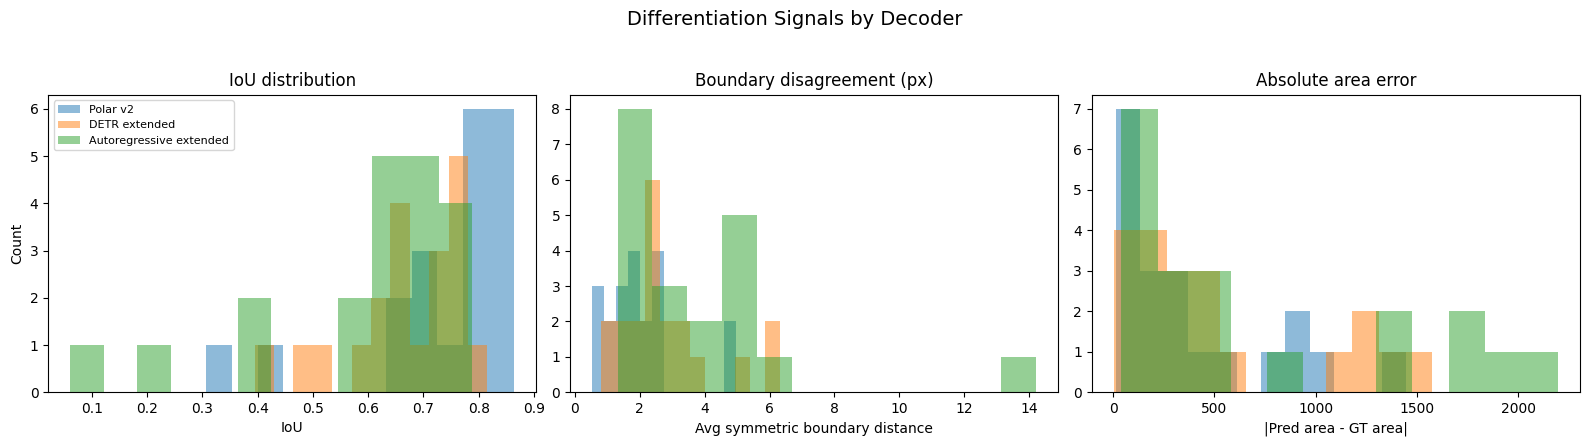

Saved: figures/differentiation_metric_distributions.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16,4.5))

for m in df['model'].unique():
    axes[0].hist(df.loc[df.model==m, 'iou'], bins=12, alpha=0.5, label=m)
axes[0].set_title('IoU distribution')
axes[0].set_xlabel('IoU')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=8)

for m in df['model'].unique():
    axes[1].hist(df.loc[df.model==m, 'boundary_dist_px'].dropna(), bins=12, alpha=0.5, label=m)
axes[1].set_title('Boundary disagreement (px)')
axes[1].set_xlabel('Avg symmetric boundary distance')

for m in df['model'].unique():
    axes[2].hist(df.loc[df.model==m, 'area_error_abs'], bins=12, alpha=0.5, label=m)
axes[2].set_title('Absolute area error')
axes[2].set_xlabel('|Pred area - GT area|')

plt.suptitle('Differentiation Signals by Decoder', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.savefig('figures/differentiation_metric_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: figures/differentiation_metric_distributions.png')

## 7) Differentiation result B: per-image model disagreement (what the system is uncertain about)

In [10]:
model_names = [m[0] for m in models_loaded]

dis_rows = []
for idx, fimg in enumerate(fixed_images):
    masks = [pred_store[(m, idx)] for m in model_names if (m, idx) in pred_store]
    if len(masks) < 2:
        continue

    # Consensus vs disagreement map
    stack = np.stack(masks, axis=0)
    vote_mean = stack.mean(axis=0)                 # [H,W] in [0,1]
    disagreement = vote_mean * (1 - vote_mean)    # max at 0.5

    dis_rows.append({
        'image_idx': idx,
        'dataset': fimg['ds_name'],
        'filename': fimg['filename'],
        'mean_disagreement': float(disagreement.mean()),
        'max_disagreement': float(disagreement.max()),
    })

df_dis = pd.DataFrame(dis_rows).sort_values('mean_disagreement', ascending=False)
display(df_dis.head(10))
df_dis.to_csv('results/per_image_model_disagreement.csv', index=False)
print('Saved: results/per_image_model_disagreement.csv')

,image_idx,dataset,filename,mean_disagreement,max_disagreement
7,7,Medetec,foot-ulcer-0028_3.png,0.012129,0.222222
4,4,Medetec,foot-ulcer-0028.png,0.010461,0.222222
18,18,AZH,baf6df704ae535e46fe2f366a58f219c_0.png,0.010423,0.222222
5,5,Medetec,foot-ulcer-0028_1.png,0.010352,0.222222
6,6,Medetec,foot-ulcer-0028_2.png,0.008691,0.222222
17,17,AZH,baba5451a41a555f6ea4355b4c53db59_1.png,0.007504,0.222222
14,14,AZH,ba4755da013537410deae3f8386d08ba_0.png,0.006104,0.222222
1,1,Medetec,foot-ulcer-0027_1.png,0.004598,0.222222
2,2,Medetec,foot-ulcer-0027_2.png,0.004317,0.222222
16,16,AZH,baba5451a41a555f6ea4355b4c53db59_0.png,0.004130,0.222222


Saved: results/per_image_model_disagreement.csv


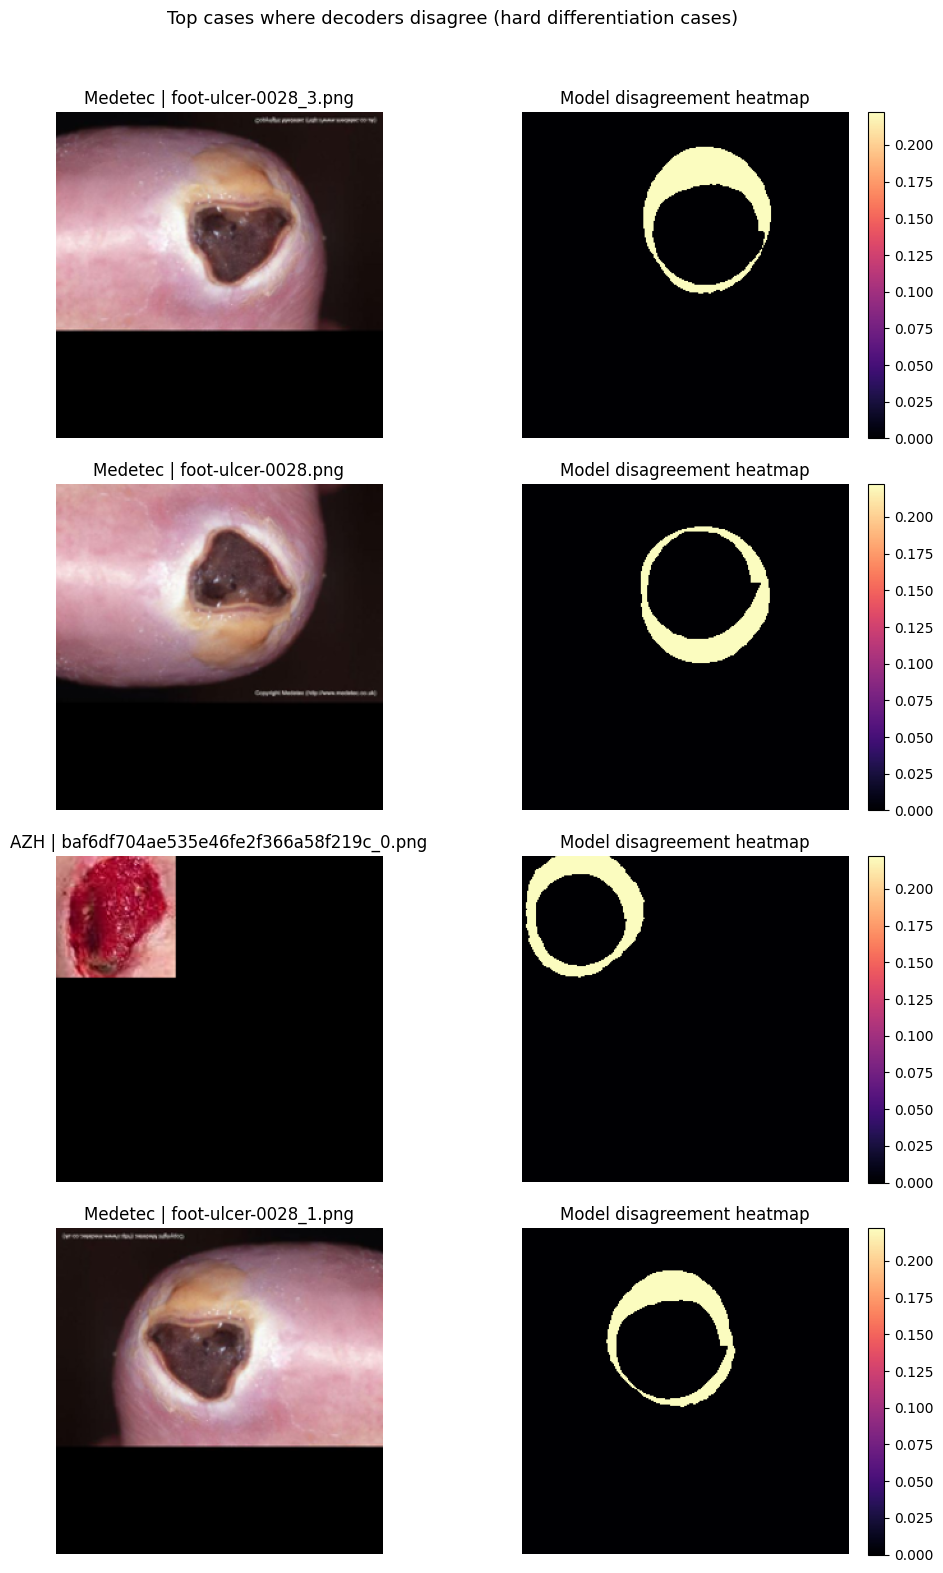

Saved: figures/top_disagreement_cases.png


In [11]:
# Visualize top disagreement cases (where differentiation is hardest)
k = min(4, len(df_dis))
if k == 0:
    print('No disagreement results to visualize.')
else:
    top_idx = df_dis.head(k)['image_idx'].tolist()
    fig, axes = plt.subplots(k, 2, figsize=(10, 4*k))
    if k == 1:
        axes = np.array([axes])

    for r, idx in enumerate(top_idx):
        fimg = fixed_images[idx]
        img_show = (fimg['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)

        masks = [pred_store[(m, idx)] for m in model_names if (m, idx) in pred_store]
        stack = np.stack(masks, axis=0)
        vote_mean = stack.mean(axis=0)
        disagreement = vote_mean * (1 - vote_mean)

        ax0, ax1 = axes[r]
        ax0.imshow(img_show)
        ax0.set_title(f"{fimg['ds_name']} | {fimg['filename']}")
        ax0.axis('off')

        hm = ax1.imshow(disagreement, cmap='magma')
        ax1.set_title('Model disagreement heatmap')
        ax1.axis('off')
        fig.colorbar(hm, ax=ax1, fraction=0.046, pad=0.04)

    plt.suptitle('Top cases where decoders disagree (hard differentiation cases)', fontsize=13)
    plt.tight_layout(rect=[0,0,1,0.96])
    plt.savefig('figures/top_disagreement_cases.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figures/top_disagreement_cases.png')

## 8) Differentiation result C: controller-oriented decision table

This section computes two distinct signal types that must not be conflated:
1. **Offline / retrospective GT-based metrics** (`offline_gt_iou_*`): require ground-truth masks and quantify how good the decoders actually were on this *labeled* test set. They are only computable here, during offline analysis — a real controller at inference time has no GT mask for a new wound image.
2. **Inference-time, GT-free uncertainty/action recommendation** (`controller_confidence`, `recommended_action`): derived only from cross-model agreement (predicted-area dispersion + model disagreement maps from section 7), which is available at runtime with no ground truth. This is the only signal a deployed controller could actually use.

In [12]:
# ─────────────────────────────────────────────────────────────────────────
# Build the controller decision table.
#
# `offline_gt_iou_mean/std` require ground-truth masks: they are retrospective
# / offline evaluation metrics only, NOT available to a controller at
# inference time on a new, unlabeled image.
#
# `controller_confidence` / `recommended_action` are computed ONLY from
# GT-free model-agreement signals (predicted-area dispersion across decoders
# and the per-image disagreement map computed in section 7), so they are
# valid to compute at inference time. This does not claim to be as accurate
# as GT-based IoU; it is documented here as an uncertainty proxy, not ground
# truth.
# ─────────────────────────────────────────────────────────────────────────
pivot_iou = df.pivot_table(index='image_idx', columns='model', values='iou', aggfunc='mean')
pivot_area = df.pivot_table(index='image_idx', columns='model', values='pred_area', aggfunc='mean')
disagreement_by_idx = {r['image_idx']: r for r in dis_rows}  # GT-free, from section 7

controller_rows = []
for idx, fimg in enumerate(fixed_images):
    if idx not in pivot_iou.index:
        continue

    iou_vals = pivot_iou.loc[idx].dropna().values
    area_vals = pivot_area.loc[idx].dropna().values

    # Offline-only (GT-derived) — retrospective evaluation, NOT usable at runtime
    offline_iou_mean = float(np.mean(iou_vals)) if len(iou_vals) > 0 else np.nan
    offline_iou_std = float(np.std(iou_vals)) if len(iou_vals) > 0 else np.nan

    # Inference-time (GT-free) features — usable at deployment
    area_cv = float(np.std(area_vals) / (np.mean(area_vals) + 1e-8)) if len(area_vals) > 0 else np.nan
    dis = disagreement_by_idx.get(idx)
    mean_disagreement = float(dis['mean_disagreement']) if dis is not None else np.nan
    max_disagreement = float(dis['max_disagreement']) if dis is not None else np.nan

    # Example inference-time policy using ONLY GT-free model-agreement signals:
    # - High confidence: low cross-decoder area dispersion + low disagreement
    # - Medium: moderate agreement
    # - Low: decoders disagree a lot (ambiguous / hard case)
    if (area_cv <= 0.12) and (mean_disagreement <= 0.05):
        confidence = 'HIGH'
        rec_action = 'Proceed autonomous trajectory'
    elif (area_cv <= 0.25) and (mean_disagreement <= 0.12):
        confidence = 'MEDIUM'
        rec_action = 'Proceed with conservative speed + verify boundary'
    else:
        confidence = 'LOW'
        rec_action = 'Require human check / fallback strategy'

    controller_rows.append({
        'image_idx': idx,
        'dataset': fimg['ds_name'],
        'filename': fimg['filename'],
        # Inference-time (GT-free) features + decision
        'pred_area_cv_across_decoders': area_cv,
        'mean_model_disagreement': mean_disagreement,
        'max_model_disagreement': max_disagreement,
        'controller_confidence': confidence,
        'recommended_action': rec_action,
        # Offline-only (GT-derived) metrics -- retrospective evaluation ONLY
        'offline_gt_iou_mean_across_decoders': offline_iou_mean,
        'offline_gt_iou_std_across_decoders': offline_iou_std,
    })

controller_df = pd.DataFrame(controller_rows)
display(controller_df.head(20))
controller_df.to_csv('results/controller_decision_table.csv', index=False)
print('Saved: results/controller_decision_table.csv')
print()
print('NOTE: controller_confidence/recommended_action use ONLY GT-free model-agreement')
print('      signals and are valid at inference time. offline_gt_iou_* columns require')
print('      ground truth and are retrospective/offline evaluation metrics only -- they')
print('      are NOT available to a controller at runtime.')

,image_idx,dataset,filename,pred_area_cv_across_decoders,mean_model_disagreement,max_model_disagreement,controller_confidence,recommended_action,offline_gt_iou_mean_across_decoders,offline_gt_iou_std_across_decoders
0,0,Medetec,foot-ulcer-0027.png,0.021101,0.003764,0.222222,HIGH,Proceed autonomous trajectory,0.761500,0.027800
1,1,Medetec,foot-ulcer-0027_1.png,0.146139,0.004598,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.747214,0.022192
2,2,Medetec,foot-ulcer-0027_2.png,0.064707,0.004317,0.222222,HIGH,Proceed autonomous trajectory,0.762424,0.035257
3,3,Medetec,foot-ulcer-0027_3.png,0.099246,0.002828,0.222222,HIGH,Proceed autonomous trajectory,0.782132,0.026924
4,4,Medetec,foot-ulcer-0028.png,0.154951,0.010461,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.746480,0.058042
5,5,Medetec,foot-ulcer-0028_1.png,0.148172,0.010352,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.709972,0.087997
6,6,Medetec,foot-ulcer-0028_2.png,0.147645,0.008691,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.738152,0.074828
7,7,Medetec,foot-ulcer-0028_3.png,0.188097,0.012129,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.711286,0.069106
8,8,AZH,b23232898bafcf304b2138af86be40b9_0.png,0.133261,0.002275,0.222222,MEDIUM,Proceed with conservative speed + verify boundary,0.639014,0.034921
9,9,AZH,b586407933e66b112820f28448783627_0.png,0.105912,0.000576,0.222222,HIGH,Proceed autonomous trajectory,0.731630,0.080689


Saved: results/controller_decision_table.csv

NOTE: controller_confidence/recommended_action use ONLY GT-free model-agreement
      signals and are valid at inference time. offline_gt_iou_* columns require
      ground truth and are retrospective/offline evaluation metrics only -- they
      are NOT available to a controller at runtime.


## 9) Qualitative panel for selected low-confidence cases

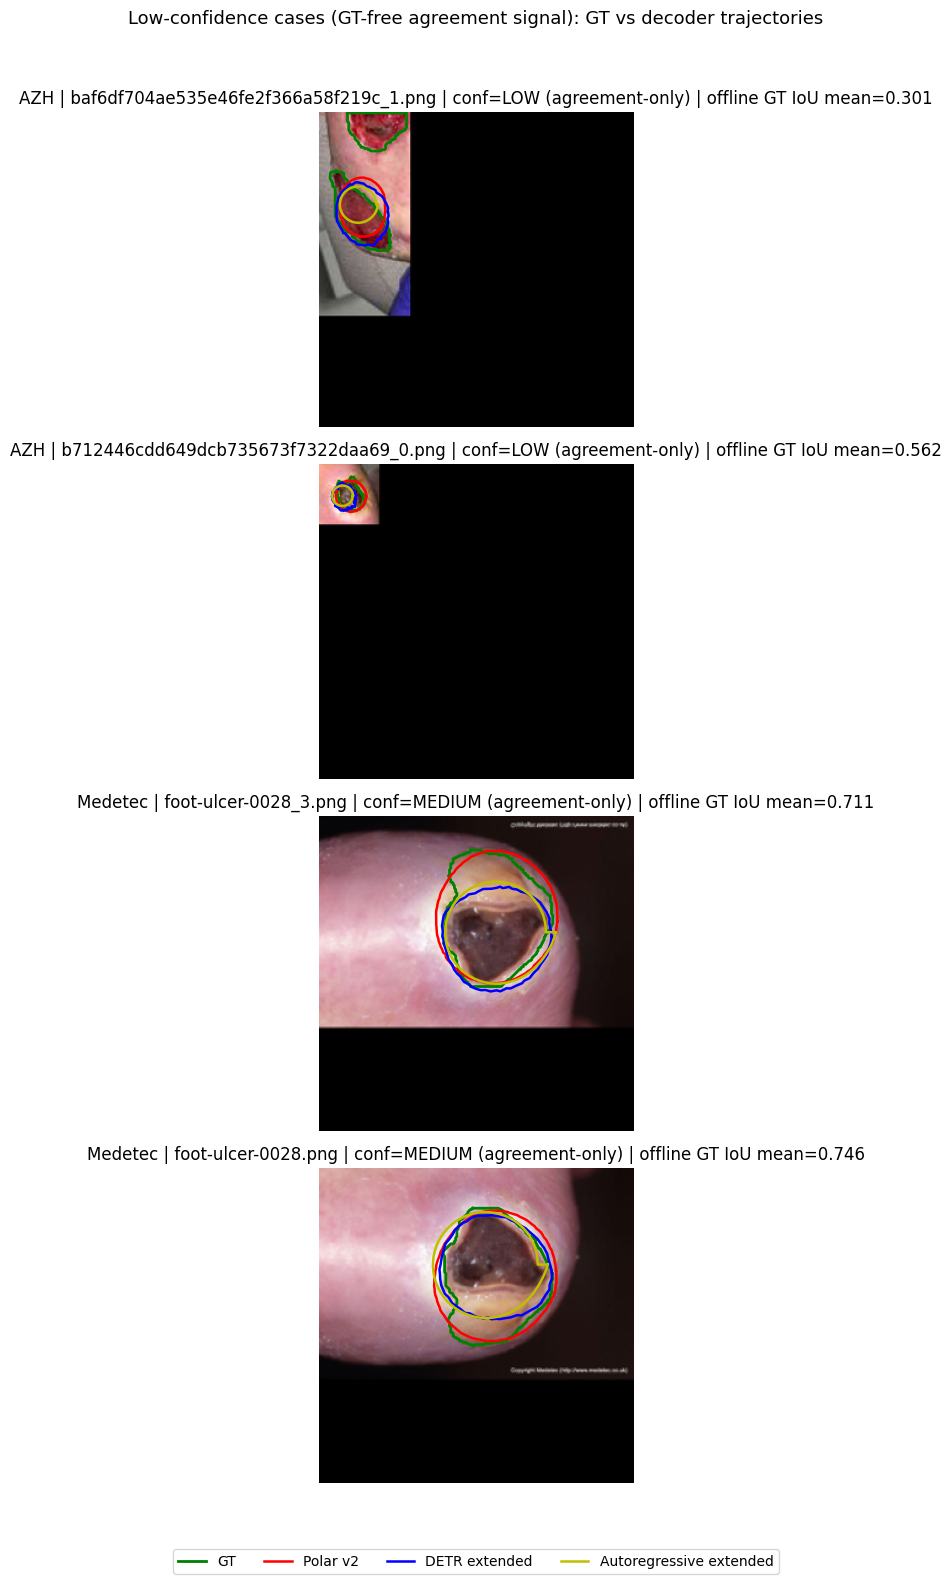

Saved: figures/low_confidence_cases_overlay.png


In [13]:
if len(controller_df) == 0:
    print('No controller rows available.')
else:
    # Prioritize LOW/MEDIUM confidence (GT-free, inference-time signal) cases,
    # then rank by disagreement -- avoids using GT-derived IoU to pick cases.
    _conf_rank = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
    sel = controller_df.assign(
        _rank=controller_df['controller_confidence'].map(_conf_rank)
    ).sort_values(
        ['_rank', 'mean_model_disagreement'], ascending=[True, False]
    ).head(min(4, len(controller_df)))
    idxs = sel['image_idx'].tolist()

    fig, axes = plt.subplots(len(idxs), 1, figsize=(10, 4*len(idxs)))
    if len(idxs) == 1:
        axes = [axes]

    color_cycle = ['r', 'b', 'y', 'm']

    for ax, idx in zip(axes, idxs):
        fimg = fixed_images[idx]
        img_show = (fimg['image'] * STD_T + MEAN_T).permute(1,2,0).numpy().clip(0,1)
        ax.imshow(img_show)

        # GT
        cnts, _ = cv2.findContours(fimg['raw_mask'].astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in cnts:
            p = c.squeeze()
            if p.ndim == 2 and len(p) > 2:
                ax.plot(np.r_[p[:,0], p[0,0]], np.r_[p[:,1], p[0,1]], 'g-', linewidth=2, label='GT')

        # Pred polygons -- reuse cached points from section 5 instead of
        # rerunning model inference for this qualitative plot.
        for j, model_entry in enumerate(models_loaded):
            mname = model_entry[0]
            pts = pts_store.get((mname, idx))
            if pts is None:
                pts = predict_points(model_entry, fimg['image'])
            ax.plot(np.r_[pts[:,0], pts[0,0]], np.r_[pts[:,1], pts[0,1]],
                    color=color_cycle[j % len(color_cycle)], linewidth=1.8, label=mname)

        row = controller_df[controller_df.image_idx == idx].iloc[0]
        ax.set_title(
            f"{fimg['ds_name']} | {fimg['filename']} | conf={row['controller_confidence']} (agreement-only) | "
            f"offline GT IoU mean={row['offline_gt_iou_mean_across_decoders']:.3f}"
        )
        ax.axis('off')

    handles, labels = axes[0].get_legend_handles_labels()
    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc='lower center', ncol=min(4, len(uniq)))
    plt.suptitle('Low-confidence cases (GT-free agreement signal): GT vs decoder trajectories', fontsize=13, y=0.98)
    plt.tight_layout(rect=[0, 0.05, 1, 0.96])
    plt.savefig('figures/low_confidence_cases_overlay.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: figures/low_confidence_cases_overlay.png')

## 10) Final summary

In [14]:
print('\n' + '='*70)
print('DIFFERENTIATION ANALYSIS COMPLETE')
print('='*70)
print(f"Models evaluated: {[m[0] for m in models_loaded]}")
print(f"Images analyzed: {len(fixed_images)}")
print(f"Datasets covered: {sorted(set(f['ds_name'] for f in fixed_images))}")
print('\nGenerated CSV outputs:')
print('  results/differentiation_summary_by_model.csv')
print('  results/per_image_model_disagreement.csv')
print('  results/controller_decision_table.csv')
print('\nGenerated figures:')
print('  figures/differentiation_metric_distributions.png')
print('  figures/top_disagreement_cases.png')
print('  figures/low_confidence_cases_overlay.png')
print('\nInterpretation guide:')
print('  - High IoU + low boundary distance => reliable differentiation (offline, GT-based)')
print('  - High cross-decoder disagreement => ambiguous/hard case (inference-time, GT-free)')
print('  - controller_confidence/recommended_action use ONLY GT-free agreement signals')
print('  - offline_gt_iou_* columns are retrospective evaluation metrics, not available at runtime')


DIFFERENTIATION ANALYSIS COMPLETE
Models evaluated: ['Polar v2', 'DETR extended', 'Autoregressive extended']
Images analyzed: 20
Datasets covered: ['AZH', 'Medetec']

Generated CSV outputs:
  results/differentiation_summary_by_model.csv
  results/per_image_model_disagreement.csv
  results/controller_decision_table.csv

Generated figures:
  figures/differentiation_metric_distributions.png
  figures/top_disagreement_cases.png
  figures/low_confidence_cases_overlay.png

Interpretation guide:
  - High IoU + low boundary distance => reliable differentiation (offline, GT-based)
  - High cross-decoder disagreement => ambiguous/hard case (inference-time, GT-free)
  - controller_confidence/recommended_action use ONLY GT-free agreement signals
  - offline_gt_iou_* columns are retrospective evaluation metrics, not available at runtime
